|<h2>Course:</h2>|<h1><a href="https://udemy.com/course/deeplearning_x/?couponCode=202508" target="_blank">A deep understanding of deep learning</a></h1>|
|-|:-:|
|<h2>Section:</h2>|<h1>More on data<h1>|
|<h2>Lecture:</h2>|<h1><b>Data noise augmentation (with devset+test)<b></h1>|

<br>

<h5><b>Teacher:</b> Mike X Cohen, <a href="https://sincxpress.com" target="_blank">sincxpress.com</a></h5>
<h5><b>Course URL:</b> <a href="https://udemy.com/course/deeplearning_x/?couponCode=202508" target="_blank">udemy.com/course/deeplearning_x/?couponCode=202508</a></h5>
<i>Using the code without the course may lead to confusion or errors.</i>

In [16]:
# import libraries
import numpy as np

import torch
import torch.nn as nn
import torch.nn.functional as F
from torchvision import datasets
from torch.utils.data import DataLoader,TensorDataset
from sklearn.model_selection import train_test_split

import matplotlib.pyplot as plt

# A function that returns a dataset with a specified size

In [17]:
# import the data
# download MNIST dataset
output_dir = 'sample_data'
mnist = datasets.MNIST(root='sample_data', download=True)

# extract labels (number IDs) and data
labelsFull = mnist.targets.numpy()
dataFull = mnist.data.numpy().reshape(mnist.data.shape[0], -1)  # flatten to 2D

print(labelsFull.shape)
print(dataFull.shape)

# normalize the data to a range of [0 1]
dataFull = dataFull / np.max(dataFull)

(60000,)
(60000, 784)


In [18]:
def double_data(data, labels, colorFlip:bool=False):
  if colorFlip == False:
    dataN  = data + torch.rand_like(data)/2
  else:
    dataN  = 1.0 - data
  dataN = dataN / torch.max(dataN)
  dataD   = torch.cat((data,dataN),axis=0)
  labelsD = torch.cat((labels,labels),axis=0)
  return dataD, labelsD

# now for the function
def makeTheDataset(dataFull, labelsFull, N, doubleTheData=False):

  # extract labels (number IDs) and remove from data
  data   = torch.tensor(dataFull[:N,:]).float()
  labels = torch.tensor(labelsFull[:N]).long()

  # make a noisy copy of ALL the data
  # if doubleTheData:
  #   data, labels = double_data(data, labels)

  # use scikitlearn to split the data
  train_data,devset_data, train_labels,devset_labels = train_test_split(data, labels, train_size=.9)

  # make a noisy copy of the TRAIN data
  if doubleTheData:
    train_data, train_labels = double_data(train_data, train_labels, True)

  # convert into PyTorch Datasets
  train_data  = TensorDataset(train_data,train_labels)
  devset_data = TensorDataset(devset_data,devset_labels)

  # translate into dataloader objects
  batchsize     = 20
  train_loader  = DataLoader(train_data,batch_size=batchsize,shuffle=True,drop_last=True)
  devset_loader = DataLoader(devset_data,batch_size=devset_data.tensors[0].shape[0])

  # NEW!! Create a test set (don't need a dataloader)
  testdata   = torch.tensor( dataFull[N:,:] ).float()
  testlabels = torch.tensor( labelsFull[N:]  ).long()

  return train_loader,devset_loader,(testdata,testlabels)

torch.Size([20, 784])
torch.Size([2, 784])
torch.Size([59988, 784])
torch.Size([59988])


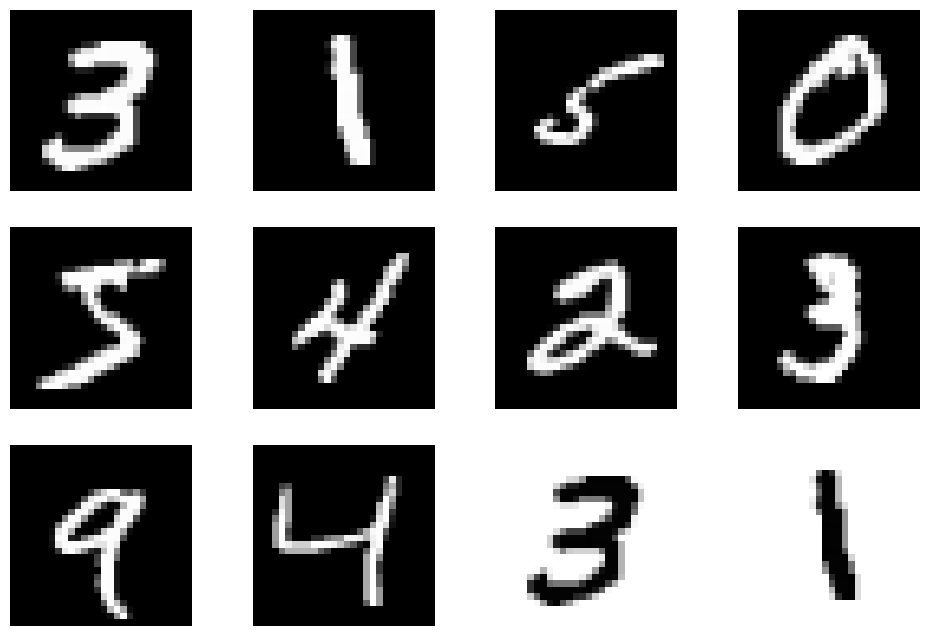

In [19]:
# visualize the images

# get some sample data
train_loader,devset_loader,testdataset = makeTheDataset(dataFull, labelsFull, 12,True)

print(train_loader.dataset.tensors[0].shape)
print(devset_loader.dataset.tensors[0].shape)
print(testdataset[0].shape)
print(testdataset[1].shape)

# pop out the data matrices
img = train_loader.dataset.tensors[0].detach()

# show the numbers
fig,ax = plt.subplots(3,4,figsize=(12,8))
for i,ax in enumerate(ax.flatten()):
  ax.imshow(np.reshape(img[i,:],(28,28)) ,cmap='gray')
  ax.axis('off')
plt.show()

# Create the DL model

In [20]:
# create a class for the model
def createTheMNISTNet():

  class mnistNet(nn.Module):
    def __init__(self):
      super().__init__()

      ### input layer
      self.input = nn.Linear(784,64)

      ### hidden layer
      self.fc1 = nn.Linear(64,32)
      self.fc2 = nn.Linear(32,32)

      ### output layer
      self.output = nn.Linear(32,10)

    # forward pass
    def forward(self,x):
      x = F.relu( self.input(x) )
      x = F.relu( self.fc1(x) )
      x = F.relu( self.fc2(x) )
      return self.output(x)

  # create the model instance
  net = mnistNet()

  # loss function
  lossfun = nn.CrossEntropyLoss()

  # optimizer
  optimizer = torch.optim.Adam(net.parameters(),lr=1e-2)

  return net,lossfun,optimizer

# Create a function that trains the model

In [21]:
# a function that trains the model

def function2trainTheModel(numepochs=50):

  # create a new model
  net,lossfun,optimizer = createTheMNISTNet()

  # initialize losses
  losses    = torch.zeros(numepochs)
  trainAcc  = []
  devsetAcc = []


  # loop over epochs
  for epochi in range(numepochs):
    
    net.train()  # put model in training mode

    # loop over training data batches
    batchAcc  = []
    batchLoss = []
    for X,y in train_loader:

      # forward pass and loss
      yHat = net(X)
      loss = lossfun(yHat,y)

      # backprop
      optimizer.zero_grad()
      loss.backward()
      optimizer.step()

      # loss from this batch
      batchLoss.append(loss.item())

      # compute accuracy
      matches = torch.argmax(yHat,axis=1) == y     # booleans (false/true)
      matchesNumeric = matches.float()             # convert to numbers (0/1)
      accuracyPct = 100*torch.mean(matchesNumeric) # average and x100
      batchAcc.append( accuracyPct )               # add to list of accuracies
    # end of batch loop...

    # now that we've trained through the batches, get their average training accuracy
    trainAcc.append( np.mean(batchAcc) )

    # and get average losses across the batches
    losses[epochi] = np.mean(batchLoss)

    # devset accuracy
    X,y = next(iter(devset_loader)) # extract X,y from devset dataloader
    net.eval()  # put model in eval mode
    with torch.no_grad(): # deactivates autograd
      yHat = net(X)
      # compare the following really long line of code to the training accuracy lines
      devsetAcc.append( 100*torch.mean((torch.argmax(yHat,axis=1)==y).float()) )

  # end epochs

  # function output
  return trainAcc,devsetAcc,losses,net

# Run an experiment showing better performance with increased N



In [22]:
# takes ~3 mins

# list of data sample sizes
samplesizes = np.arange(500,4001,500)

# initialize results matrix
resultsSingle = np.zeros((len(samplesizes),3))
resultsDouble = np.zeros((len(samplesizes),3))

numepochs = 50
for idx,ssize in enumerate(samplesizes):

  ### without doubling the data!

  # generate a dataset and train the model
  train_loader,devset_loader,testdataset = makeTheDataset(dataFull, labelsFull, ssize,False)
  trainAcc,devsetAcc,losses,net = function2trainTheModel(numepochs=numepochs)

  # grab the results
  resultsSingle[idx,0] = np.mean(trainAcc[-5:])
  resultsSingle[idx,1] = np.mean(devsetAcc[-5:])
  resultsSingle[idx,2] = torch.mean(losses[-5:]).item()

  ### with doubling the data!

  # generate a dataset and train the model
  train_loader,devset_loader,testdataset = makeTheDataset(dataFull, labelsFull, ssize,True)
  trainAcc,devsetAcc,losses,net          = function2trainTheModel(numepochs=numepochs)

  # grab the results
  resultsDouble[idx,0] = np.mean(trainAcc[-5:])
  resultsDouble[idx,1] = np.mean(devsetAcc[-5:])
  resultsDouble[idx,2] = torch.mean(losses[-5:]).item()


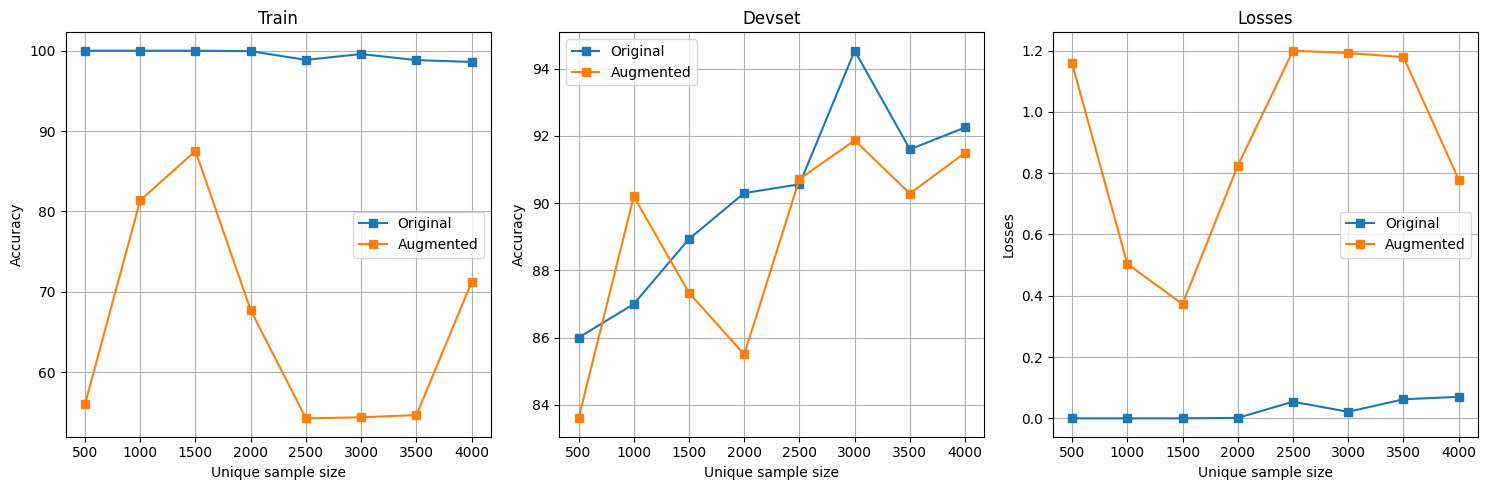

In [23]:
# Let's see what the results look like!
fig,ax = plt.subplots(1,3,figsize=(15,5))

# axis and title labels
titles    = ['Train','Devset','Losses']
yaxlabels = ['Accuracy','Accuracy','Losses']

# common features
for i in range(3):

  # plot the lines
  ax[i].plot(samplesizes,resultsSingle[:,i],'s-',label='Original')
  ax[i].plot(samplesizes,resultsDouble[:,i],'s-',label='Augmented')

  # make it look nicer
  ax[i].set_ylabel(yaxlabels[i])
  ax[i].set_title(titles[i])
  ax[i].legend()
  ax[i].set_xlabel('Unique sample size')
  ax[i].grid('on')

plt.tight_layout()
plt.show()

# Now for test accuracy!

In [24]:
# we need to re-run the models for N=500

samplesize = 500
numepochs = 50

train_loader,devset_loader,testdataset  = makeTheDataset(dataFull, labelsFull, samplesize,False)
trainAccO,devsetAccO,lossesO,netO       = function2trainTheModel(numepochs=numepochs) # O = original

train_loader,devset_loader,testdataset  = makeTheDataset(dataFull, labelsFull, samplesize,True)
trainAccA,devsetAccA,lossesA,netA       = function2trainTheModel(numepochs=numepochs) # A = augmented

In [25]:
# Now for the real test! On the test data!

# extract the test data
X,y = testdataset

# run the original model
yHat = netO(X)
testO = 100*torch.mean((torch.argmax(yHat,axis=1)==y).float())

# And the augmented model
yHat = netA(X)
testA = 100*torch.mean((torch.argmax(yHat,axis=1)==y).float())

# print the results!
print( f'ORIGINAL MODEL (N={samplesize}):\n  Train: {trainAccO[-1]:.2f}%, devset: {devsetAccO[-1]:.2f}%, test: {testO:.2f}%\n\n')
print(f'AUGMENTED MODEL (N={samplesize}):\n  Train: {trainAccA[-1]:.2f}%, devset: {devsetAccA[-1]:.2f}%, test: {testA:.2f}%')


ORIGINAL MODEL (N=500):
  Train: 100.00%, devset: 78.00%, test: 80.98%


AUGMENTED MODEL (N=500):
  Train: 92.67%, devset: 84.00%, test: 81.16%


In [42]:
# 1) It looks like noise augmentation only helped for small sample sizes (<1000). Write code to run a new experiment that
#    reproduces this experiment 10 times, but only using sample sizes [500,1000,2000]. Then make a plot showing the increase
#    in devset accuracy for all 10 runs. That will help determine whether our finding above was a quirk of sampling
#    variability or a meaningful effect.
#

# list of data sample sizes
samplesizes = np.array([500,1000,2000])

# initialize results matrix
nRepeats = 10
resultsSingle = np.zeros((nRepeats, len(samplesizes),3))
resultsDouble = np.zeros((nRepeats, len(samplesizes),3))
numepochs = 50

for i in range(nRepeats):
  for idx,ssize in enumerate(samplesizes):

    ### without doubling the data!

    # generate a dataset and train the model
    train_loader,devset_loader,testdataset = makeTheDataset(dataFull, labelsFull, ssize,False)
    trainAcc,devsetAcc,losses,net = function2trainTheModel(numepochs=numepochs)

    # grab the results
    resultsSingle[i,idx,0] = np.mean(trainAcc[-5:])
    resultsSingle[i,idx,1] = np.mean(devsetAcc[-5:])
    resultsSingle[i,idx,2] = torch.mean(losses[-5:]).item()

    ### with doubling the data!

    # generate a dataset and train the model
    train_loader,devset_loader,testdataset = makeTheDataset(dataFull, labelsFull, ssize,True)
    trainAcc,devsetAcc,losses,net          = function2trainTheModel(numepochs=numepochs)

    # grab the results
    resultsDouble[i,idx,0] = np.mean(trainAcc[-5:])
    resultsDouble[i,idx,1] = np.mean(devsetAcc[-5:])
    resultsDouble[i,idx,2] = torch.mean(losses[-5:]).item()

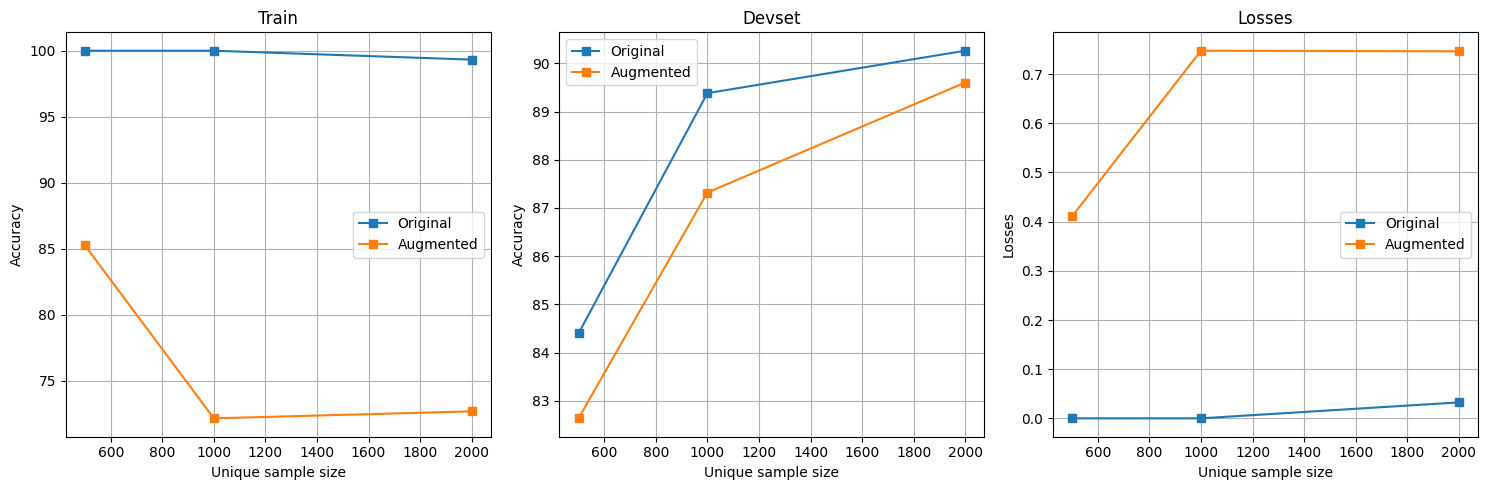

In [43]:
# Let's see what the results look like!
fig,ax = plt.subplots(1,3,figsize=(15,5))

# axis and title labels
titles    = ['Train','Devset','Losses']
yaxlabels = ['Accuracy','Accuracy','Losses']

resultsSingle_mean = np.mean(resultsSingle, axis=0)
resultsDouble_mean = np.mean(resultsDouble, axis=0)

# common features
for i in range(3):

  # plot the lines
  ax[i].plot(samplesizes,resultsSingle_mean[:,i],'s-',label='Original')
  ax[i].plot(samplesizes,resultsDouble_mean[:,i],'s-',label='Augmented')

  # make it look nicer
  ax[i].set_ylabel(yaxlabels[i])
  ax[i].set_title(titles[i])
  ax[i].legend()
  ax[i].set_xlabel('Unique sample size')
  ax[i].grid('on')

plt.tight_layout()
plt.show()

# Additional explorations

In [ ]:
# 1) It looks like noise augmentation only helped for small sample sizes (<1000). Write code to run a new experiment that
#    reproduces this experiment 10 times, but only using sample sizes [500,1000,2000]. Then make a plot showing the increase
#    in devset accuracy for all 10 runs. That will help determine whether our finding above was a quirk of sampling
#    variability or a meaningful effect.
#
# 2) Immediately after loading in the MNIST data (top of the script), there is the following code:
#    dataFull[:,1:] = dataFull[:,1:] / np.max(dataFull)
#    This is different from the corresponding normalization code in the previous MNIST videos. Do you need the [:,1:]?
#    What happens when you change that line to: dataFull = dataFull / np.max(dataFull)
#    Can you still train the model?
# Answer: The [:,1:] is not needed, it normilizes all pixels except first one. It does not affect training the model.
#
# 3) We augmented the data using noisy copies. Another idea is to augment the dataset using color-flipped copies. Thus,
#    the numbers will be black on a white background. Try it and see how the results compare to the noise-added version!
# Answer: The augmented train accuracy seems to be much worse (arounf 70% avg over all unique sample sizes). It needs more investigation over multiple runs.
# The test accuracy for N = 500 unique samples is only slightly worse than the origial model, though.
#